ARTI308 - Machine Learning

# Lab 4 Solution: Data Quality Assessment & Preprocessing (Netflix Dataset)

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load Dataset

In [2]:
df = pd.read_csv('../data/netflix_titles.csv')
print('Shape:', df.shape)
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Data Quality Assessment
### 2.1 Check Data Types

In [3]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

`date_added` should be datetime, and `duration` should be split into numeric value and unit to support analysis.

### 2.2 Convert Incorrect Data Types

In [4]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract duration value (numeric) and duration unit (min/Season/Seasons)
df['duration_value'] = pd.to_numeric(df['duration'].str.extract(r'(\d+)')[0], errors='coerce')
df['duration_unit'] = df['duration'].str.extract(r'([A-Za-z]+)$')[0]

df[['date_added', 'duration', 'duration_value', 'duration_unit']].head()

,date_added,duration,duration_value,duration_unit
0,2021-09-25,90 min,90.0,min
1,2021-09-24,2 Seasons,2.0,Seasons
2,2021-09-24,1 Season,1.0,Season
3,2021-09-24,1 Season,1.0,Season
4,2021-09-24,2 Seasons,2.0,Seasons


In [5]:
df.dtypes

show_id                   object
type                      object
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
description               object
duration_value           float64
duration_unit             object
dtype: object

Now we can perform date-based operations and numeric preprocessing on `duration_value`.

## 3. Handling Missing Values
### 3.1 Detect Missing Values

In [6]:
df.isna().sum()

show_id              0
type                 0
title                0
director          2634
cast               825
country            831
date_added          98
release_year         0
rating               4
duration             3
listed_in            0
description          0
duration_value       3
duration_unit        3
dtype: int64

### 3.2 Demonstration: Introduce Artificial Missing Values

In [7]:
df_missing = df.copy()
df_missing.loc[0:5, 'duration_value'] = np.nan

df_missing[['title', 'duration', 'duration_value']].head(10)

,title,duration,duration_value
0,Dick Johnson Is Dead,90 min,NaN
1,Blood & Water,2 Seasons,NaN
2,Ganglands,1 Season,NaN
3,Jailbirds New Orleans,1 Season,NaN
4,Kota Factory,2 Seasons,NaN
5,Midnight Mass,1 Season,NaN
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
8,The Great British Baking Show,9 Seasons,9.0
9,The Starling,104 min,104.0


In [8]:
print('Original shape:', df.shape)
print('After removing some values:', df_missing.shape)
df_missing.isna().sum()[['duration_value']]

Original shape: (8807, 14)
After removing some values: (8807, 14)


duration_value    9
dtype: int64

### Strategy 1: Remove Records

In [9]:
df_removed = df_missing.dropna(subset=['duration_value'])
print('Shape after dropna:', df_removed.shape)
df_removed.isna().sum()[['duration_value']]

Shape after dropna: (8798, 14)


duration_value    0
dtype: int64

### Strategy 2: Mean Imputation

In [10]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['duration_value'] = df_imputed_mean['duration_value'].fillna(df_imputed_mean['duration_value'].mean())

df_imputed_mean[['title', 'duration_value']].head(10)

,title,duration_value
0,Dick Johnson Is Dead,69.883496
1,Blood & Water,69.883496
2,Ganglands,69.883496
3,Jailbirds New Orleans,69.883496
4,Kota Factory,69.883496
5,Midnight Mass,69.883496
6,My Little Pony: A New Generation,91.000000
7,Sankofa,125.000000
8,The Great British Baking Show,9.000000
9,The Starling,104.000000


### Strategy 3: Median Imputation

In [11]:
df_imputed_median = df_missing.copy()
df_imputed_median['duration_value'] = df_imputed_median['duration_value'].fillna(df_imputed_median['duration_value'].median())

df_imputed_median[['title', 'duration_value']].head(10)

,title,duration_value
0,Dick Johnson Is Dead,88.0
1,Blood & Water,88.0
2,Ganglands,88.0
3,Jailbirds New Orleans,88.0
4,Kota Factory,88.0
5,Midnight Mass,88.0
6,My Little Pony: A New Generation,91.0
7,Sankofa,125.0
8,The Great British Baking Show,9.0
9,The Starling,104.0


## 4. Handling Outliers
We will detect outliers in `duration_value` using the IQR method.

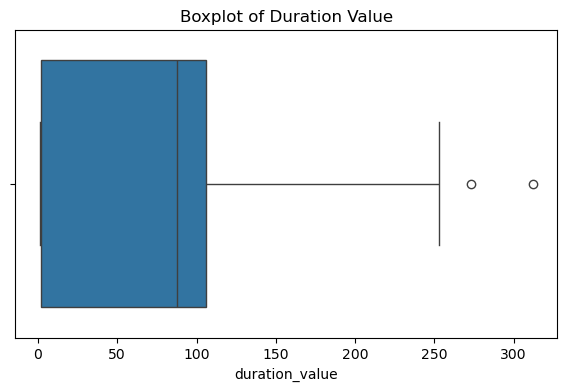

In [12]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=df['duration_value'])
plt.title('Boxplot of Duration Value')
plt.show()

### Detect Outliers Using IQR

In [13]:
Q1 = df['duration_value'].quantile(0.25)
Q3 = df['duration_value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower bound:', lower)
print('Upper bound:', upper)

outliers = df[(df['duration_value'] < lower) | (df['duration_value'] > upper)]
outliers[['title', 'type', 'duration', 'duration_value']].head(10)

Q1: 2.0
Q3: 106.0
IQR: 104.0
Lower bound: -154.0
Upper bound: 262.0


,title,type,duration,duration_value
717,Headspace: Unwind Your Mind,Movie,273 min,273.0
4253,Black Mirror: Bandersnatch,Movie,312 min,312.0


### Remove Outliers

In [14]:
df_no_outliers = df[(df['duration_value'] >= lower) & (df['duration_value'] <= upper)]
print('Original shape:', df.shape)
print('After removing outliers:', df_no_outliers.shape)

Original shape: (8807, 14)
After removing outliers: (8802, 14)


### Capping Outliers (Percentile Method)

In [15]:
lower_cap = df['duration_value'].quantile(0.05)
upper_cap = df['duration_value'].quantile(0.95)

df_capped = df.copy()
df_capped['duration_value_capped'] = df_capped['duration_value'].clip(lower=lower_cap, upper=upper_cap)

print('Lower cap:', lower_cap)
print('Upper cap:', upper_cap)
df_capped[['duration_value', 'duration_value_capped']].describe()

Lower cap: 1.0
Upper cap: 139.0


,duration_value,duration_value_capped
count,8804.000000,8804.000000
mean,69.846888,68.876647
std,50.814828,49.068376
min,1.000000,1.000000
25%,2.000000,2.000000
50%,88.000000,88.000000
75%,106.000000,106.000000
max,312.000000,139.000000


## 5. Data Transformation - Normalization
We will scale `release_year` and `duration_value`.

In [16]:
numeric_df = df[['release_year', 'duration_value']].dropna().copy()
numeric_df.head()

,release_year,duration_value
0,2020,90.0
1,2021,2.0
2,2021,1.0
3,2021,1.0
4,2021,2.0


### Min-Max Normalization

In [17]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
df_normalized = numeric_df.copy()
df_normalized[['release_year', 'duration_value']] = minmax_scaler.fit_transform(
    df_normalized[['release_year', 'duration_value']]
)

df_normalized.head()

,release_year,duration_value
0,0.989583,0.286174
1,1.000000,0.003215
2,1.000000,0.000000
3,1.000000,0.000000
4,1.000000,0.003215


### Z-Score Normalization

In [18]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
df_standardized = numeric_df.copy()
df_standardized[['release_year', 'duration_value']] = standard_scaler.fit_transform(
    df_standardized[['release_year', 'duration_value']]
)

df_standardized.head()

,release_year,duration_value
0,0.659824,0.396622
1,0.773200,-1.335255
2,0.773200,-1.354935
3,0.773200,-1.354935
4,0.773200,-1.335255


## Check Correlation Before Applying PCA

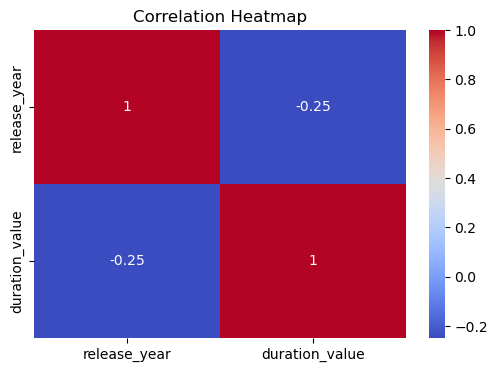

In [19]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_standardized[['release_year', 'duration_value']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 6. Data Reduction - Principal Component Analysis (PCA)

In [20]:
from sklearn.decomposition import PCA

X = df_standardized[['release_year', 'duration_value']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.62459077 0.37540923]
Total explained variance: 1.0


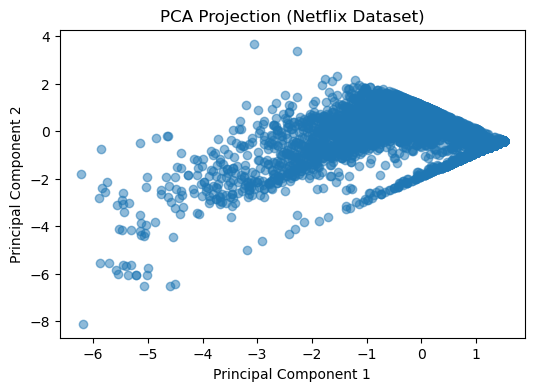

In [21]:
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5)
plt.title('PCA Projection (Netflix Dataset)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

This notebook reproduces the Lab 4 preprocessing workflow on `netflix_titles.csv`.